In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils

large_data_dir = gf_utils.large_data_dir

In [2]:
gf_dir = large_data_dir + 'gf_CL_mega/BC1_giftwrap/'
adata_path = large_data_dir + 'CL_mega_WTA.h5ad'

In [3]:
genotyping_mode = 'gapfill'
betaine_condition = 'betaine'

43207807 UMIs found
Filtering probe reads based on read threshold (0) and min percent supporting (0.9), 43129460 UMIs remaining (99.82%)
Filtering cells based on min counts (0) and genes (0) in WTA
Filtering probe reads based on cell barcodes in adata, 38657371 UMIs remaining (89.47%)


(<Figure size 300x300 with 1 Axes>,
 <Axes: xlabel='log10(PCR duplicate count)', ylabel='Number of UMIs'>)

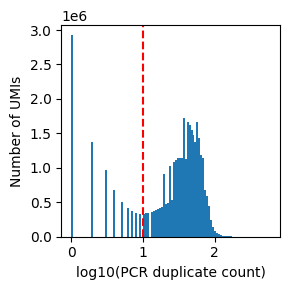

In [4]:
manifest = gf_utils.get_manifest(gf_dir)

manifest['type'] = 'gapfill'
manifest.loc[manifest['name'] == 'SDHA c.1643A>G','gap_probe_sequence'] = 'GATG' ## manual fix

manifest.loc[manifest['name'].str.contains('0bp'),'type'] = '0bp_control'
manifest['variant'] = None ### not relevant for gapfill but maintained for consistency

probe_reads = gf_utils.get_input_probe_reads(gf_dir, read_threshold=0, min_percent_supporting=0.9, adata_path=adata_path)
probe_reads = probe_reads.merge(manifest[['gap_probe_sequence','gapfill_from_transcriptome','name','type','gapfill_start','variant']], left_on='probe_idx',right_index=True, how='left')

read_threshold = 10
gf_utils.plot_reads_per_umi(probe_reads=probe_reads, read_threshold=read_threshold)


In [5]:
probe_reads = probe_reads.loc[probe_reads['pcr_duplicate_count'] > read_threshold].copy()

In [6]:
adata = gf_utils.read_adata(adata_path)

In [7]:
predicted_genotypes = pd.read_csv('../data/4cl_mega_predicted_genotypes.csv',sep=',')
predicted_genotypes = predicted_genotypes.pivot(index='name', columns='cell_type', values='genotype_from_bulk').copy()
predicted_genotypes = predicted_genotypes.replace({'homozygous_ref': 'wt', 'homozygous_alt': 'mutated'})

probe_reads = probe_reads.merge(predicted_genotypes.reset_index().melt(id_vars='name', var_name='cell_type', value_name='genotype'), on = ['name','cell_type'], how='left')
probe_reads['genotype'] = probe_reads['genotype'].fillna('wt') ### assume wt if not labeled otherwise

In [8]:
### add allele calls to probe_reads

probe_reads['allele_call'] = np.select(
    [
        probe_reads['type'] == 'gapfill',
        probe_reads['type'] == '0bp_genotyping'
    ],
    [
        np.where(
            probe_reads['gapfill'] == probe_reads['gapfill_from_transcriptome'], 'ref',
            np.where(probe_reads['gapfill'] == probe_reads['gap_probe_sequence'], 'alt', None)
        ),
        np.where(
            probe_reads['gapfill_start'].notna(), 'ref', 'alt' ### for dual probes assign ref if gapfill_start is not null (then probes were found in wt transcriptome)
        )
    ],
    default=None
)


In [9]:
### define likelihoods for gapfill and dual probes to use for cell genotype calls

p_wt_given_wt_gapfill = 0.99
p_wt_given_wt_dual = 0.9

probe_reads['p_gapfill_given_ref'] = np.select(
    [
        probe_reads['type'] == 'gapfill',
        probe_reads['type'] == '0bp_genotyping'
    ],
    [
        probe_reads['allele_call'].map({'ref': p_wt_given_wt_gapfill, 'alt': 1 - p_wt_given_wt_gapfill}),
        probe_reads['allele_call'].map({'ref': p_wt_given_wt_dual, 'alt': 1 - p_wt_given_wt_dual})
    ],
    default=np.nan
)

probe_reads['p_gapfill_given_alt'] = np.select(
    [
        probe_reads['type'] == 'gapfill',
        probe_reads['type'] == '0bp_genotyping'
    ],
    [
        probe_reads['allele_call'].map({'ref': 1 - p_wt_given_wt_gapfill, 'alt': p_wt_given_wt_gapfill}),
        probe_reads['allele_call'].map({'ref': 1 - p_wt_given_wt_dual, 'alt': p_wt_given_wt_dual})
    ],
    default=np.nan
)
probe_reads['pcr_swap_likelihood'] = 0 ### we filtered UMIs with low pcr duplicate counts so we are not using this likelihood in the model
probe_reads.reset_index(inplace=True, drop=True)

variants = probe_reads.loc[probe_reads['type'] == genotyping_mode]['name'].unique().tolist()

### add genotypes to adata
adata = gf_utils.get_genotyped_adata(probe_reads.loc[probe_reads['type'] ==  genotyping_mode].drop('probe_idx',axis=1).rename(columns={'name':'probe_idx'}).dropna(subset='allele_call'), adata, variants)


In [10]:
# Calculate the proportion of 'ref' allele calls among wt genotypes for each probe (name)
wt_allele_calls = probe_reads.loc[
    (probe_reads['type'] == genotyping_mode) &
    (probe_reads['genotype'] == 'wt') &
    (probe_reads['allele_call'].isin(['ref', 'alt']))
]

p_ref_given_wt = wt_allele_calls.groupby('name')['allele_call'].apply(lambda x: (x == 'ref').mean())


# Calculate the proportion of 'alt' allele calls among mutated genotypes for each probe (name)
mutated_allele_calls = probe_reads.loc[
    (probe_reads['type'] == genotyping_mode) &
    (probe_reads['genotype'] == 'mutated') &
    (probe_reads['allele_call'].isin(['ref', 'alt']))
]

p_alt_given_mutated = mutated_allele_calls.groupby('name')['allele_call'].apply(lambda x: (x == 'alt').mean())


In [11]:
probe_counts = probe_reads.loc[
    (probe_reads['type'] == genotyping_mode) & (probe_reads['allele_call'].notna())
][['name', 'probe_barcode']].value_counts().rename('total_count').reset_index()

barcode_counts = adata.obs['BC'].str.replace('BC00','').astype(int).value_counts()
probe_counts['n_cells'] = probe_counts['probe_barcode'].map(barcode_counts)
probe_counts['mean_per_cell'] = probe_counts['total_count'] / probe_counts['n_cells']

mean_counts = probe_counts.set_index('name')['mean_per_cell']
n_cells = probe_counts.set_index('name')['n_cells']
prop_genotyped = adata.obsm['genotypes'].notna().sum() / probe_counts.set_index('name')['n_cells']

summary = pd.DataFrame([p_alt_given_mutated, p_ref_given_wt, prop_genotyped, mean_counts, n_cells], index = ['p_alt_given_mutated','p_ref_given_wt','prop_genotyped','mean_counts','n_cells']).transpose()
summary = summary.reindex(variants) ### make sure to include all variants even if they have no counts
summary['prop_genotyped'] = summary['prop_genotyped'].fillna(0)
summary['mean_counts'] = summary['mean_counts'].fillna(0)

## add variant side if dual probes
if genotyping_mode == '0bp_genotyping':
    summary = summary.merge(probe_reads.loc[probe_reads['type'] == '0bp_genotyping'][['name','variant']].drop_duplicates().set_index('name'), left_index=True, right_index=True, how='left')


In [12]:
control_counts = probe_reads.loc[probe_reads['name'].str.contains('0bp')]['name'].value_counts().reset_index()
control_counts['gene'] = control_counts['name'].str.split(' ',expand=True)[0]
control_counts = control_counts.groupby('gene')['count'].mean().reset_index()
control_counts.columns = ['gene','0bp_count']

summary['gene'] = summary.index.str.split(' ',expand=True).get_level_values(0)
summary['0bp_count'] = summary['gene'].map(control_counts.set_index('gene')['0bp_count'].to_dict())
summary['mean_0bp_count'] = summary['0bp_count'] / summary['n_cells']
summary['gapfill_count'] = summary['mean_counts'] * len(adata)
summary['efficiency'] = (summary['gapfill_count'] / summary['0bp_count'])
summary['gap_length'] = summary.index.map(manifest.set_index('name')['gapfill_from_transcriptome'].str.len().to_dict())
summary['overlaps_within_set'] = summary.index.map(manifest.set_index('name')['overlaps_within_set'].to_dict())
summary['overlaps_with_flex'] = summary.index.map(manifest.set_index('name')['overlaps_with_flex'].to_dict())


In [13]:
summary.to_csv('../output/' + genotyping_mode + '_' + betaine_condition + '_mega_summary.csv')

In [14]:
adata.obsm['predicted_genotypes'] = pd.DataFrame(adata.obs['cell_type']).merge(predicted_genotypes.transpose(), left_on='cell_type', right_index=True, how='left').drop('cell_type', axis=1)

## save genotyped adata
pd.set_option('future.no_silent_downcasting', True)
adata.__class__(
    obs=adata.obs.copy(),
    var=adata.var.copy(),
    obsm={
        'X_umap': adata.obsm['X_umap'].copy(),
        'genotypes': adata.obsm['genotypes'].reindex(variants, axis=1).replace({'wt': 0, 'mutated': 1, 'heterozygous': 2}).astype(float).copy(),
        'predicted_genotypes': adata.obsm['predicted_genotypes'].reindex(variants, axis=1).replace({'wt': 0, 'mutated': 1, 'heterozygous': 2}).astype(float).copy()
    }
).write_h5ad('../output/' + genotyping_mode + '_' + betaine_condition + '_mega_genotyped_adata.h5ad')